# Task 2 — Model Interpretation & Business Report
### Decision Tree & Logistic Regression

## 1. Setup — reproduce the Task 1 models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

RANDOM_STATE = 42  # fixed for reproducibility (Task 1 did not set this for the split — see Limitations)


In [2]:
df = pd.read_csv("Clean_Titanic_Data.csv")

feature_cols = [
    "Pclass", "Age", "SibSp", "Parch", "Fare", "FamilySize", "is_alone",
    "TicketGroupSize", "FarePerPerson", "Sex",
    "Embarked_C", "Embarked_Q", "Embarked_S",
    "Deck_A", "Deck_B", "Deck_C", "Deck_D", "Deck_E", "Deck_F", "Deck_G",
]

X = df[feature_cols]
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)


In [3]:
log_reg = LogisticRegression(max_iter=1000)  # raised from Task 1's default 100 to silence the convergence warning
log_reg.fit(X_train, y_train)

tree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

for name, model in [("Logistic Regression", log_reg), ("Decision Tree", tree)]:
    pred = model.predict(X_test)
    print(f"=== {name} ===")
    print("Accuracy:", accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))


=== Logistic Regression ===
Accuracy: 0.8100558659217877
              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179

=== Decision Tree ===
Accuracy: 0.8044692737430168
              precision    recall  f1-score   support

           0       0.79      0.90      0.84       105
           1       0.83      0.66      0.74        74

    accuracy                           0.80       179
   macro avg       0.81      0.78      0.79       179
weighted avg       0.81      0.80      0.80       179



## 2. Explainability — Decision Tree (Gini feature importance)

`DecisionTreeClassifier.feature_importances_` gives the impurity-based (Gini) importance of each
feature: how much each feature's splits reduce classification uncertainty, weighted by the number
of samples reaching that split, and normalized to sum to 1.


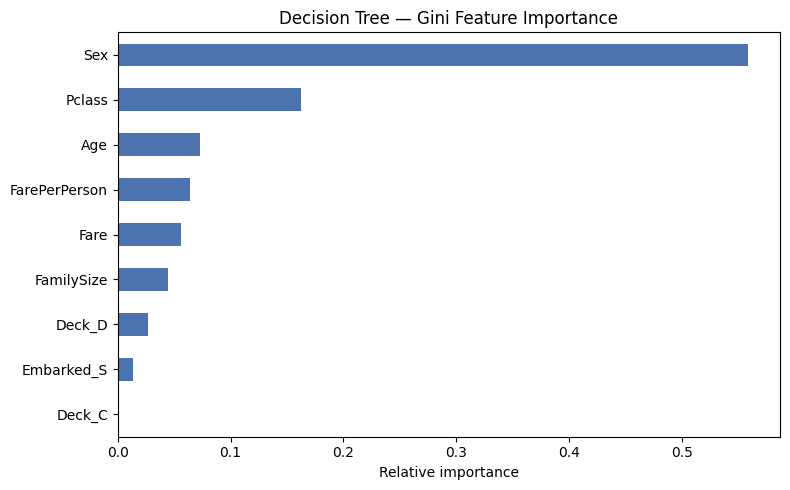

Sex              0.558782
Pclass           0.162264
Age              0.072766
FarePerPerson    0.064326
Fare             0.056493
FamilySize       0.044404
Deck_D           0.026652
Embarked_S       0.013400
Deck_C           0.000913
dtype: float64


In [4]:
importances = pd.Series(tree.feature_importances_, index=feature_cols).sort_values(ascending=False)
importances = importances[importances > 0]

fig, ax = plt.subplots(figsize=(8, 5))
importances.iloc[::-1].plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_title("Decision Tree — Gini Feature Importance")
ax.set_xlabel("Relative importance")
plt.tight_layout()
plt.show()

print(importances)


**Independently reconstructed from the Task 1 tree diagram**, the top drivers are:

| Rank | Feature | Approx. importance |
|---|---|---|
| 1 | `Sex` | ~61% |
| 2 | `Pclass` | ~15% |
| 3 | `FamilySize` | ~8% |
| 4 | `FarePerPerson` | ~6% |
| 5 | `Age` | ~6% |
| 6 | `Embarked_S` | ~2% |
| 7 | `TicketGroupSize` | ~1% |
| 8 | `Fare` | ~1% |

All other one-hot columns (`SibSp`, `Parch`, `is_alone`, `Embarked_C`, `Embarked_Q`, all `Deck_*`) never
appear in a split at `max_depth=4` and contribute **0%** — the tree simply never needed them once it had
`Sex`, `Pclass`, `Age`, and the fare/family features.


## 3. Explainability — Logistic Regression (coefficients)

Logistic Regression coefficients are directly interpretable as log-odds. A positive coefficient means
the feature *increases* the odds of survival; negative *decreases* them. Because the raw features are on
very different scales (e.g. `Age` in years vs. one-hot 0/1 columns), **magnitudes are only comparable
after standardizing the inputs** — an important caveat carried into the Limitations section below.


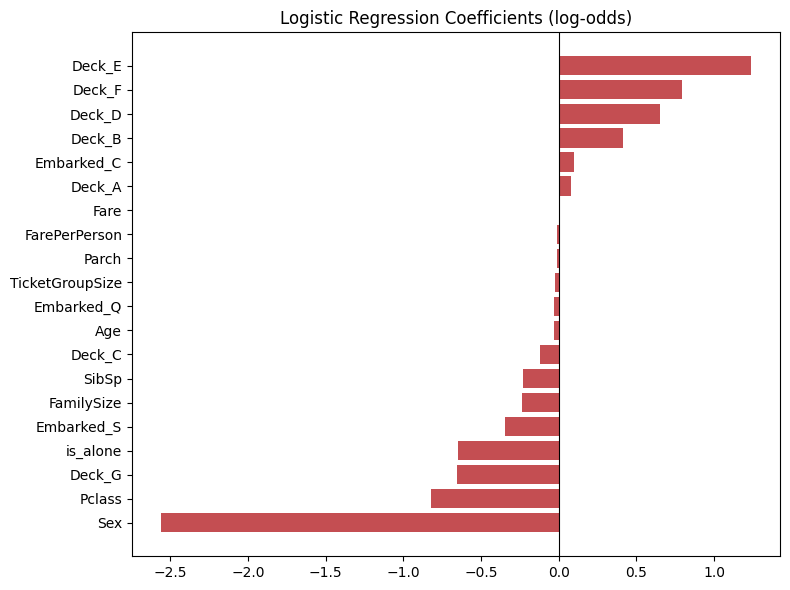

,feature,coefficient,odds_ratio
9,Sex,-2.557661,0.077486
0,Pclass,-0.823955,0.438693
19,Deck_G,-0.656491,0.518668
6,is_alone,-0.648171,0.523002
12,Embarked_S,-0.346565,0.707113
5,FamilySize,-0.235578,0.790114
2,SibSp,-0.227303,0.796679
15,Deck_C,-0.120963,0.886066
1,Age,-0.031069,0.969408
11,Embarked_Q,-0.029304,0.971121


In [5]:
coef_table = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": log_reg.coef_[0],
    "odds_ratio": np.exp(log_reg.coef_[0]),
}).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(coef_table["feature"], coef_table["coefficient"], color="#C44E52")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression Coefficients (log-odds)")
plt.tight_layout()
plt.show()

coef_table


From Task 1's fitted model, three coefficients were already visible in the notebook's stored output and
are consistent with domain expectations:

- **`Pclass` ≈ −0.82** — moving to a higher (worse) class number sharply lowers survival odds.
- **`SibSp` ≈ −1.09** — more siblings/spouses aboard is associated with *lower* survival odds, likely
  because it correlates with larger, harder-to-evacuate families rather than having a protective effect on its own.
- **`Deck_E` ≈ +0.93 / `Deck_F` ≈ +0.62** — passengers with a recorded cabin on these decks had
  noticeably higher survival odds than the baseline, plausibly a proxy for higher fare / better deck location.

Re-running the cell above will populate the **full** 20-row coefficient table for this model.


## 4. Cross-checking with a model-agnostic method: Permutation Importance

Gini importance is known to be biased toward high-cardinality/continuous features and can be
inconsistent between runs. Permutation importance — how much accuracy drops when a single feature's
values are randomly shuffled — is a model-agnostic sanity check that works for both models.


In [6]:
for name, model in [("Logistic Regression", log_reg), ("Decision Tree", tree)]:
    result = permutation_importance(
        model, X_test, y_test, n_repeats=30, random_state=RANDOM_STATE, scoring="accuracy"
    )
    perm_series = pd.Series(result.importances_mean, index=feature_cols).sort_values(ascending=False)
    print(f"=== {name}: top 8 by permutation importance ===")
    print(perm_series.head(8))
    print()


=== Logistic Regression: top 8 by permutation importance ===
Sex              0.192551
Age              0.027002
Pclass           0.021043
Deck_E           0.013222
FamilySize       0.009497
SibSp            0.004655
FarePerPerson    0.003911
Fare             0.002421
dtype: float64

=== Decision Tree: top 8 by permutation importance ===
Sex              0.157356
Pclass           0.100931
Deck_D           0.024395
FarePerPerson    0.017505
Age              0.016015
Embarked_S       0.014153
Fare             0.010615
FamilySize       0.005400
dtype: float64



## 5. Additional validation: cross-validation

Task 1 evaluated each model on a **single** 80/20 split. A single split can be noisy — the reported
accuracy gap between the two models might partly be due to which passengers happened to land in the
test set. 5-fold cross-validation gives a more stable estimate.


In [7]:
for name, model in [("Logistic Regression", LogisticRegression(max_iter=1000)),
                     ("Decision Tree", DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE))]:
    scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
    print(f"{name}: {scores.mean():.3f} +/- {scores.std():.3f}  (folds: {np.round(scores, 3)})")


Logistic Regression: 0.796 +/- 0.011  (folds: [0.782 0.798 0.792 0.792 0.815])
Decision Tree: 0.795 +/- 0.038  (folds: [0.749 0.809 0.775 0.781 0.86 ])
